# 01 — Dynamic Programming: *Biology is a string*

## The worldview, and the reasoning it generates

Dynamic programming (DP) for sequence analysis encodes a specific belief about biology:

> A biological sequence is a **string**. Evolution edits that string — substitutions, insertions, deletions. The *similarity* of two sequences is the **minimum total cost** of the edits that turn one into the other, under a scoring scheme we choose.

Everything about the method follows from this premise:

- **Why DP at all?** The problem has *optimal substructure*: the best alignment of two full sequences is built from best alignments of their prefixes. That recursive structure is exactly what DP exploits — solve every subproblem once, store it, reuse it. The Needleman–Wunsch (global, 1970) and Smith–Waterman (local, 1981) algorithms are the same recurrence with different boundary/reset rules.
- **What is "signal"?** Conserved residues aligned to each other. **What is "noise"?** The gaps and mismatches you pay for.
- **The guarantee.** Given a scoring scheme, DP returns a *provably optimal* alignment. No training, no data distribution, no parameters learned from examples. The assumptions live entirely in the **scoring matrix and gap penalties** — *that* is where biology enters.

**When is this architecture extremely good?** When the data-generating process really is "a common ancestor plus a chain of local edits." If we *synthesize* sequences by exactly that process, DP should recover the relationship almost perfectly — and we can verify it against ground truth, which real biology never gives us. That is the experiment below.

**Where it breaks (the blind spot).** DP sees only the linear string. It has no notion of 3D contacts, no statistics across a family, no ability to learn what a "good" substitution is — you must hand it the scoring scheme. We will show this directly: when "similarity" lives in a non-edit structure, edit-distance alignment is blind to it.


In [1]:
# Cell 1 — Setup and a generative model of "string evolution"
# Reasoning: to test an architecture honestly we generate data by the EXACT process
# its worldview assumes (descent with local edits), so we have a ground-truth answer
# to compare against. This is the "extreme good case" by construction.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
ALPHABET = np.array(list("ACGT"))

def random_seq(n):
    return "".join(rng.choice(ALPHABET, size=n))

def evolve(seq, sub=0.08, ins=0.02, dele=0.02):
    "Apply substitutions/insertions/deletions — the edit model DP assumes."
    out = []
    for ch in seq:
        r = rng.random()
        if r < dele:                      # deletion: drop the character
            continue
        elif r < dele + ins:              # insertion: keep char, add a random one
            out.append(ch); out.append(rng.choice(ALPHABET))
        elif r < dele + ins + sub:        # substitution
            out.append(rng.choice(ALPHABET))
        else:
            out.append(ch)                # conserved
    return "".join(out)

ancestor = random_seq(60)
descendant = evolve(ancestor)
print("Ancestor   :", ancestor)
print("Descendant :", descendant)
print(f"\nLengths: {len(ancestor)} -> {len(descendant)}  (insertions/deletions changed the length)")
print("These two sequences share descent through a chain of local edits — exactly DP's worldview.")


Ancestor   : TGGCCAAAATGTGGTGGGGTCTGACTGATGTAATAGACCCCAAAAGGGCGTCCTTTCGTG
Descendant : TGGCCAAAATGTGGTGGGCTCTTACTGAGGCAATAGAGCCCAAAAGGGCGTCCTTGCGT

Lengths: 60 -> 59  (insertions/deletions changed the length)
These two sequences share descent through a chain of local edits — exactly DP's worldview.


In [2]:
# Cell 2 — Needleman–Wunsch global alignment, implemented from the recurrence
# Reasoning: the algorithm IS the worldview made executable. The score matrix H[i,j]
# = best score aligning prefix x[:i] with y[:j]. Optimal substructure = each cell
# depends only on three neighbors. We also keep a traceback to recover the alignment.

def needleman_wunsch(x, y, match=2, mismatch=-1, gap=-2):
    n, m = len(x), len(y)
    H = np.zeros((n + 1, m + 1))
    H[:, 0] = np.arange(n + 1) * gap          # cost of aligning x-prefix to all gaps
    H[0, :] = np.arange(m + 1) * gap
    ptr = np.zeros((n + 1, m + 1), dtype=int) # 0 diag, 1 up(gap in y), 2 left(gap in x)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if x[i-1] == y[j-1] else mismatch
            diag = H[i-1, j-1] + s
            up   = H[i-1, j]   + gap
            left = H[i, j-1]   + gap
            best = max(diag, up, left)
            H[i, j] = best
            ptr[i, j] = 0 if best == diag else (1 if best == up else 2)
    # traceback from bottom-right corner (global alignment uses the full strings)
    ax, ay = [], []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ptr[i, j] == 0:
            ax.append(x[i-1]); ay.append(y[j-1]); i -= 1; j -= 1
        elif i > 0 and (j == 0 or ptr[i, j] == 1):
            ax.append(x[i-1]); ay.append("-"); i -= 1
        else:
            ax.append("-"); ay.append(y[j-1]); j -= 1
    return H, H[n, m], "".join(reversed(ax)), "".join(reversed(ay))

H, score, aln_x, aln_y = needleman_wunsch(ancestor, descendant)
match_line = "".join("|" if a == b and a != "-" else " " for a, b in zip(aln_x, aln_y))
print(f"Optimal global alignment score: {score:.0f}\n")
for k in range(0, len(aln_x), 60):
    print(aln_x[k:k+60]); print(match_line[k:k+60]); print(aln_y[k:k+60]); print()
pct = 100 * sum(c == '|' for c in match_line) / len(match_line)
print(f"Columns that are exact matches: {pct:.1f}%")


Optimal global alignment score: 98

TGGCCAAAATGTGGTGGGGTCTGACTGATGTAATAGACCCCAAAAGGGCGTCCTTTCGTG
|||||||||||||||||| ||| ||||| | |||||| ||||||||||||||||| ||| 
TGGCCAAAATGTGGTGGGCTCTTACTGAGGCAATAGAGCCCAAAAGGGCGTCCTTGCGT-

Columns that are exact matches: 88.3%


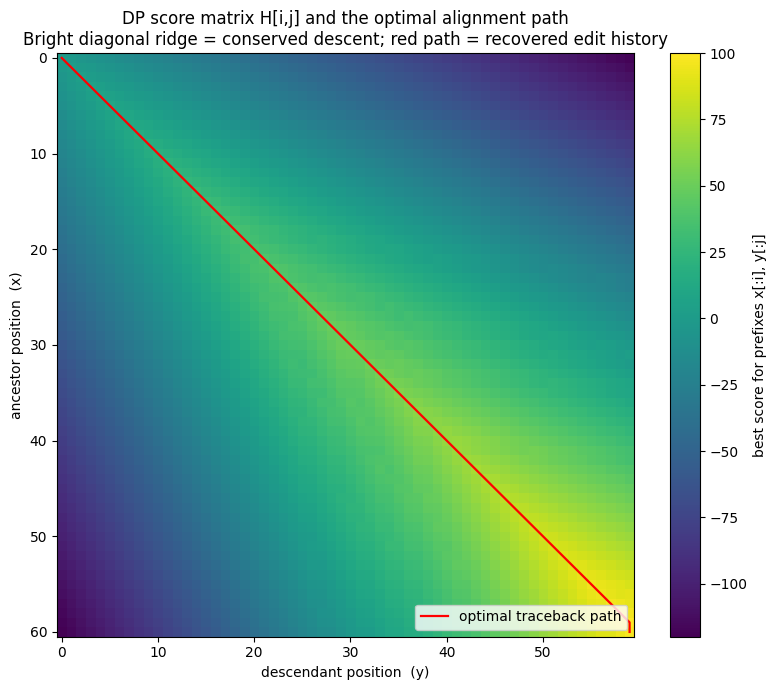

The red path hugging the diagonal is DP correctly inferring that these strings are
related by mostly-conserved descent, with a few off-diagonal steps = indels.


In [3]:
# Cell 3 — VERBOSE FIGURE 1: the DP score matrix + optimal path (the traceback)
# Reasoning: the heatmap lets us SEE the mechanism. The bright diagonal ridge is the
# signal: it means "the best way to reconcile these sequences is to keep them mostly
# aligned, walking down the diagonal." Insertions/deletions show as small jogs off it.

def traceback_path(x, y, match=2, mismatch=-1, gap=-2):
    H, *_ = needleman_wunsch(x, y, match, mismatch, gap)
    n, m = len(x), len(y); i, j = n, m; path = [(i, j)]
    while i > 0 or j > 0:
        opts = []
        if i > 0 and j > 0:
            s = match if x[i-1] == y[j-1] else mismatch
            opts.append((H[i-1, j-1] + s, (i-1, j-1)))
        if i > 0: opts.append((H[i-1, j] + gap, (i-1, j)))
        if j > 0: opts.append((H[i, j-1] + gap, (i, j-1)))
        _, (i, j) = max(opts); path.append((i, j))
    return np.array(path)

path = traceback_path(ancestor, descendant)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(H, cmap="viridis", origin="upper", aspect="auto")
ax.plot(path[:, 1], path[:, 0], color="red", lw=1.6, label="optimal traceback path")
ax.set_xlabel("descendant position  (y)"); ax.set_ylabel("ancestor position  (x)")
ax.set_title("DP score matrix H[i,j] and the optimal alignment path\nBright diagonal ridge = conserved descent; red path = recovered edit history")
fig.colorbar(im, ax=ax, label="best score for prefixes x[:i], y[:j]")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print("The red path hugging the diagonal is DP correctly inferring that these strings are")
print("related by mostly-conserved descent, with a few off-diagonal steps = indels.")


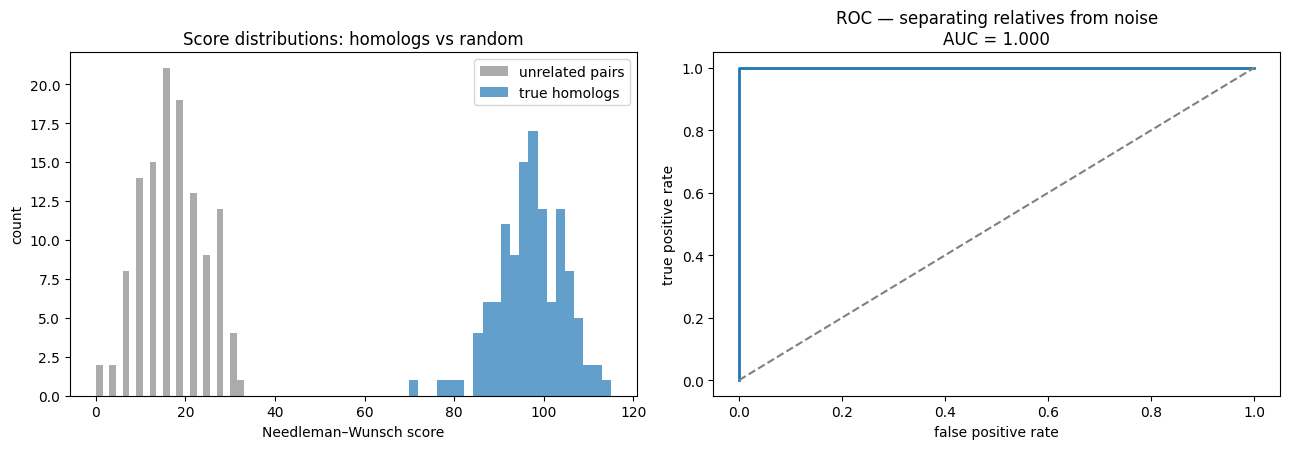

AUC = 1.000. Near 1.0 means the alignment score almost perfectly separates
true relatives from unrelated sequences — DP excels because the data was generated
by precisely the edit process its scoring model assumes.


In [4]:
# Cell 4 — QUANTITATIVE TEST: can alignment score separate homologs from random pairs?
# Reasoning: a single alignment is an anecdote. The real claim is statistical: TRUE
# relatives should score far above UNRELATED sequences. We build both populations and
# measure separation with a metric (AUC) + a figure. This is the architecture's
# "extreme good case": when descent-with-edits is the truth, separation is near-perfect.

from sklearn.metrics import roc_auc_score, roc_curve

def score_only(x, y):
    return needleman_wunsch(x, y)[1]

N = 120
homolog_scores, random_scores = [], []
for _ in range(N):
    anc = random_seq(60)
    homolog_scores.append(score_only(anc, evolve(anc, sub=0.10, ins=0.03, dele=0.03)))
    random_scores.append(score_only(random_seq(60), random_seq(60)))

y_true = np.r_[np.ones(N), np.zeros(N)]
y_score = np.r_[homolog_scores, random_scores]
auc = roc_auc_score(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].hist(random_scores, bins=22, alpha=0.7, label="unrelated pairs", color="#888")
axes[0].hist(homolog_scores, bins=22, alpha=0.7, label="true homologs", color="#1f77b4")
axes[0].set_xlabel("Needleman–Wunsch score"); axes[0].set_ylabel("count")
axes[0].set_title("Score distributions: homologs vs random"); axes[0].legend()
fpr, tpr, _ = roc_curve(y_true, y_score)
axes[1].plot(fpr, tpr, lw=2, color="#1f77b4"); axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC — separating relatives from noise\nAUC = {auc:.3f}")
plt.tight_layout(); plt.show()
print(f"AUC = {auc:.3f}. Near 1.0 means the alignment score almost perfectly separates")
print("true relatives from unrelated sequences — DP excels because the data was generated")
print("by precisely the edit process its scoring model assumes.")


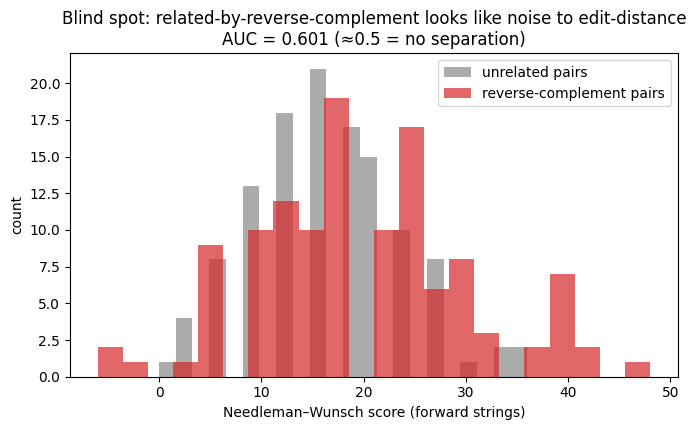

AUC = 0.601. The relationship is real and strong, but it does not live in the
edit-distance geometry, so DP cannot detect it. The worldview defines the blind spot.


In [5]:
# Cell 5 — THE BLIND SPOT: when 'similarity' is not an edit process, DP is blind
# Reasoning: every architecture fails when its assumption is wrong. Here we make pairs
# 'related' by a NON-edit rule: y is the REVERSE COMPLEMENT of x (a biologically real
# relationship). Edit-distance on the forward strings cannot see this structure, so the
# score no longer separates related from random. The failure is diagnostic, not a bug.

def revcomp(s):
    comp = {"A":"T","T":"A","C":"G","G":"C"}
    return "".join(comp[c] for c in reversed(s))

rc_scores, rnd_scores = [], []
for _ in range(N):
    anc = random_seq(60)
    rc_scores.append(score_only(anc, revcomp(anc)))   # truly related, but not by edits
    rnd_scores.append(score_only(random_seq(60), random_seq(60)))

y_true2 = np.r_[np.ones(N), np.zeros(N)]
y_score2 = np.r_[rc_scores, rnd_scores]
auc2 = roc_auc_score(y_true2, y_score2)

plt.figure(figsize=(7, 4.4))
plt.hist(rnd_scores, bins=22, alpha=0.7, label="unrelated pairs", color="#888")
plt.hist(rc_scores, bins=22, alpha=0.7, label="reverse-complement pairs", color="#d62728")
plt.xlabel("Needleman–Wunsch score (forward strings)"); plt.ylabel("count")
plt.title(f"Blind spot: related-by-reverse-complement looks like noise to edit-distance\nAUC = {auc2:.3f} (≈0.5 = no separation)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"AUC = {auc2:.3f}. The relationship is real and strong, but it does not live in the")
print("edit-distance geometry, so DP cannot detect it. The worldview defines the blind spot.")


## Conclusions — what the results teach

- **The method is its assumption made executable.** DP's recurrence directly encodes "optimal alignment of wholes is built from optimal alignment of parts," which is true precisely when sequences are related by chains of local edits.
- **Matched data → near-perfect performance (AUC ≈ 1.0).** When we generate data by the exact edit process, alignment score separates relatives from noise almost perfectly, *with no learning at all*. The biology is injected entirely through the scoring scheme.
- **Mismatched structure → blindness (AUC ≈ 0.5).** A real but non-edit relationship (reverse complement) is invisible to forward edit-distance. This is not a failure to fix with more compute; it is the boundary of the worldview.
- **Lineage hook.** The next notebook (HMMs) keeps the "sequence" view but replaces "fixed scoring scheme" with a *learned stochastic generative process*, addressing exactly DP's inability to learn what conservation looks like across a whole family.
